In [13]:
# Install MALLET 2.0.8RC3 from the official site
!wget http://mallet.cs.umass.edu/dist/mallet-2.0.8RC3.zip -O ~/mallet-2.0.8RC3.zip

# Unzip MALLET
!unzip ~/mallet-2.0.8RC3.zip -d ~/
!rm ~/mallet-2.0.8RC3.zip

# Rename the folder for convenience
!mv ~/mallet-2.0.8RC3 ~/mallet-2.0.8

# Define the path to the "mallet" binary
import os
mallet_dir = os.path.expanduser('~/mallet-2.0.8')
path_to_mallet = os.path.join(mallet_dir, 'bin', 'mallet')
print(f"Path to MALLET: {path_to_mallet}")

# Optionally check Java version
!java -version

--2026-09-19 02:50:15--  http://mallet.cs.umass.edu/dist/mallet-2.0.8RC3.zip
Resolving mallet.cs.umass.edu (mallet.cs.umass.edu)... 128.119.246.70
Connecting to mallet.cs.umass.edu (mallet.cs.umass.edu)|128.119.246.70|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://mallet.cs.umass.edu/dist/mallet-2.0.8RC3.zip [following]
--2026-09-19 02:50:15--  https://mallet.cs.umass.edu/dist/mallet-2.0.8RC3.zip
Connecting to mallet.cs.umass.edu (mallet.cs.umass.edu)|128.119.246.70|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16179018 (15M) [application/zip]
Saving to: ‘/home/codespace/mallet-2.0.8RC3.zip’

/home/codespace/mal 100%[===================>]  15.43M  77.4MB/s    in 0.2s    

2026-09-19 02:50:15 (77.4 MB/s) - ‘/home/codespace/mallet-2.0.8RC3.zip’ saved [16179018/16179018]

Archive:  /home/codespace/mallet-2.0.8RC3.zip
   creating: /home/codespace/mallet-2.0.8RC3/
   creating: /home/codespace/mallet-2.0.8RC3/bin/
  inflating

In [16]:
%pip install numpy openpyxl matplotlib pandas scipy seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# -*- coding: utf-8 -*-
"""
Integrated script for MALLET-based topic modeling with per-file Fisher’s Exact
filtering and stopword exclusion. UTF-8 friendly.
Outputs:
  - Topic keys
  - Per-document topic distributions
  - Excel workbook with:
      • Topic tokens
      • Token counts per document
      • Topic probabilities per document
  - Separate Excel workbook with top-document titles per topic

Graphical output (heatmap & boxplots) is disabled in this pipeline.
See plotting_helpers.py for on-demand plotting.
"""


import os
import csv
import time
from pathlib import Path
from collections import Counter

import pandas as pd
from scipy.stats import fisher_exact
import little_mallet_wrapper
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import pickle

# Change this path to point to the local MALLET binary in the current directory.
# For example, place the mallet-2.0.8 folder in the same directory as this script.
# Then use os.path.join(...) relative to the current working directory (codespace).
mallet_dir = os.path.expanduser('~/mallet-2.0.8')
path_to_mallet = os.path.join(mallet_dir, 'bin', 'mallet')

# These will be set by main() and picked up by plotting_helpers.py
OUTPUT_DIR = None
NUM_TOPICS = None

def tokenize_file(filepath):
    """Load a UTF-8 text file and split on whitespace (preserves accents)."""
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read().split()

def list_txt_files(directory):
    """Return a sorted list of all .txt filenames in a directory."""
    return sorted(fn for fn in os.listdir(directory) if fn.endswith(".txt"))

def list_csv_files(directory):
    """
    Recursively find all .csv files under a directory, skipping
    any .ipynb_checkpoints folders.
    """
    csv_paths = []
    for root, dirs, files in os.walk(directory):
        if ".ipynb_checkpoints" in dirs:
            dirs.remove(".ipynb_checkpoints")
        for fn in files:
            if fn.lower().endswith(".csv"):
                csv_paths.append(os.path.join(root, fn))
    return csv_paths

def choose_directory(prompt):
    """
    Display a numbered list of immediate subdirectories (plus current dir)
    and return the full path selected by the user.
    """
    cwd = os.getcwd()
    base = Path(cwd).name
    subdirs = [
        d for d in os.listdir(cwd)
        if os.path.isdir(os.path.join(cwd, d)) and d != ".ipynb_checkpoints"
    ]
    options = [(os.path.join(cwd, d), f"{base}/{d}") for d in subdirs]
    options.append((cwd, base))

    print(prompt)
    for i, (_, label) in enumerate(options, start=1):
        print(f"{i}. {label}")

    while True:
        try:
            choice = int(input("Enter number: ").strip())
            if 1 <= choice <= len(options):
                return options[choice - 1][0]
        except ValueError:
            pass
        print("Invalid choice, please try again.")

def choose_files(filenames):
    """
    Let user pick one or more filenames by:
      - indices ("2" or "1,3")
      - index ranges ("1-4")
      - prefix matching ("report")
      - or the keyword "all" to select every file.
    Returns a sorted, unique list of chosen filenames.
    """
    print("Available files:")
    for i, fn in enumerate(filenames, start=1):
        print(f"{i}. {fn}")
    choice = input("Select files (indices, ranges, prefix, or 'all'): ").strip().lower()

    if choice == "all":
        return filenames.copy()

    selected = []
    for part in choice.split(","):
        part = part.strip()
        if part == "all":
            return filenames.copy()
        if "-" in part:
            a, b = map(int, part.split("-"))
            selected.extend(filenames[a - 1:b])
        elif part.isdigit():
            selected.append(filenames[int(part) - 1])
        else:
            selected.extend(fn for fn in filenames if fn.startswith(part))
    return sorted(set(selected))

def choose_csv_file(csv_paths):
    """
    Prompt the user to select one CSV from a list of paths.
    Returns the chosen filepath.
    """
    cwd = os.getcwd()
    base = Path(cwd).name
    print("Select your stopwords CSV:")
    for i, full in enumerate(csv_paths, start=1):
        rel = os.path.relpath(full, cwd)
        print(f"{i}. {base}/{rel}")

    while True:
        try:
            choice = int(input("Enter number: ").strip())
            if 1 <= choice <= len(csv_paths):
                return csv_paths[choice - 1]
        except ValueError:
            pass
        print("Invalid choice, please try again.")

def read_stopwords(filepath):
    """Load stopwords from a CSV, splitting on commas and trimming whitespace."""
    sw = []
    with open(filepath, "r", encoding="utf-8") as f:
        for row in csv.reader(f):
            for cell in row:
                sw.extend(cell.split(","))
    return [w.strip() for w in sw if w.strip()]

def get_fishers(word, freq_dict, rate_dict, alternative="greater"):
    """
    Perform Fisher’s Exact Test on one token:
        [[observed, total-observed],
         [expected, total-expected]]
    Returns the p-value.
    """
    observed = freq_dict.get(word, 0)
    total = sum(freq_dict.values())
    expected = round(rate_dict.get(word, 0) * total)
    table = [
        [observed, total - observed],
        [expected, total - expected]
    ]
    _, pval = fisher_exact(table, alternative=alternative)
    return pval

def calculate_rate_dictionary(rate_files, rate_dir):
    """
    Build a background rate dictionary from reference documents.
    Returns a mapping { token: relative_frequency }.
    """
    counter = Counter()
    total_tokens = 0
    for fn in rate_files:
        tokens = tokenize_file(os.path.join(rate_dir, fn))
        counter.update(tokens)
        total_tokens += len(tokens)
    return {tok: cnt / total_tokens for tok, cnt in counter.items()}

def prepare_training_data(files, directory, stopwords, rate_dict, alpha):
    """
    For each file:
      1. Tokenize and count every token.
      2. Exclude stopwords and tokens with Fisher p-value ≥ alpha.
      3. Collect filtered document text and raw token counts.
    Prints per-file progress with elapsed time.
    Returns:
      - docs: list of filtered document strings for MALLET input
      - distributions: list of Counter objects of raw token counts
    """
    docs = []
    distributions = []
    total = len(files)
    overall_start = time.time()

    for idx, fn in enumerate(files, start=1):
        file_start = time.time()
        print(f"[{idx}/{total}] ⏳ Processing '{fn}'... ")

        path = os.path.join(directory, fn)
        tokens = tokenize_file(path)
        freq = Counter(tokens)

        filtered = [
            w for w in tokens
            if w not in stopwords and get_fishers(w, freq, rate_dict) < alpha
        ]
        docs.append(" ".join(filtered))
        distributions.append(freq)

        elapsed = time.time() - file_start
        kept = len(filtered)
        before = len(tokens)
        pct = (kept / before * 100) if before else 0
        print(f"done in {elapsed:.1f}s – kept {kept}/{before} tokens ({pct:.1f}%).")

    total_elapsed = time.time() - overall_start
    print(f"[Done] Prepared {total} documents in {total_elapsed:.1f}s.\n")
    return docs, distributions

def train_topic_model(training_docs, num_topics, output_dir):
    """
    Train a MALLET model via little_mallet_wrapper
    Returns:
      - topics: list of token lists (topic keys)
      - doc_topics: list of probability lists (per-document topic distributions)
    """
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    # Make sure MALLET is installed and that path_to_mallet points to the local file in the codespace.
    little_mallet_wrapper.quick_train_topic_model(
        path_to_mallet,
        output_dir,
        num_topics,
        training_docs
    )

    key_file = os.path.join(output_dir, f"mallet.topic_keys.{num_topics}")
    topics = little_mallet_wrapper.load_topic_keys(key_file)

    dist_file = os.path.join(output_dir, f"mallet.topic_distributions.{num_topics}")
    doc_topics = little_mallet_wrapper.load_topic_distributions(dist_file)

    return topics, doc_topics

def save_results_to_excel(excel_path, topics, token_distributions, doc_topics, files):
    """
    Create an Excel workbook with:
      1) 'Topics' sheet: one row per topic (Topic#, top tokens...)
      2) One sheet per document: raw token counts (removing '_stemmed' suffix)
      3) 'DocTopicDist' sheet: topic probabilities per document
    """
    wb = Workbook()
    ws0 = wb.active
    ws0.title = "Topics"
    for idx, topic in enumerate(topics):
        ws0.append([f"Topic {idx}"] + topic)

    for fn, dist in zip(files, token_distributions):
        sheet_name = Path(fn).stem.replace("_stemmed", "")
        sheet = wb.create_sheet(title=sheet_name)
        df = pd.DataFrame.from_dict(dist, orient="index", columns=["count"])
        for row in dataframe_to_rows(df, index=True, header=True):
            sheet.append(row)

    ws3 = wb.create_sheet(title="DocTopicDist")
    header = ["Document"] + [f"Topic{t}" for t in range(len(topics))]
    ws3.append(header)
    for fn, probs in zip(files, doc_topics):
        doc_name = Path(fn).stem.replace("_stemmed", "")
        ws3.append([doc_name] + [round(p, 4) for p in probs])

    wb.save(excel_path)

def save_top_titles_excel(xlsx_path, topics, training_docs, doc_topics, doc_titles, n_docs):
    """
    Save the top n_docs document titles per topic into an Excel file,
    one sheet per topic named 'Topic{#}', and remove the default blank sheet.
    """
    wb = Workbook()
    default_sheet = wb.active
    wb.remove(default_sheet)

    for t_idx in range(len(topics)):
        ws = wb.create_sheet(title=f"Topic{t_idx}")
        ws.append(["Probability", "Document Title"])
        for prob, doc in little_mallet_wrapper.get_top_docs(
            training_docs, doc_topics, t_idx, n=n_docs
        ):
            title = doc_titles.get(doc, Path(doc).stem)
            ws.append([round(prob, 4), title])

    wb.save(xlsx_path)

def input_float(prompt, min_val=None, max_val=None, default=None):
    """Prompt until the user enters a valid float (and optionally within range)."""
    while True:
        # Add default value to prompt if it exists
        if default is not None:
            prompt_with_default = f"{prompt} [default: {default}] "
        else:
            prompt_with_default = prompt
        
        resp = input(prompt_with_default).strip()
        
        # Return default if response is empty
        if not resp and default is not None:
            return default
            
        try:
            val = float(resp)
            if min_val is not None and val < min_val:
                print(f"Value must be at least {min_val}.")
                continue
            if max_val is not None and val > max_val:
                print(f"Value must be at most {max_val}.")
                continue
            return val
        except ValueError:
            print("Invalid input, please enter a valid number.")

def input_int(prompt, min_val=None, max_val=None):
    """Prompt until the user enters a valid integer (and optionally within range)."""
    while True:
        resp = input(prompt).strip()
        try:
            val = int(resp)
            if min_val is not None and val < min_val:
                print(f"Value must be at least {min_val}.")
                continue
            if max_val is not None and val > max_val:
                print(f"Value must be at most {max_val}.")
                continue
            return val
        except ValueError:
            print("Invalid input, please enter a valid integer.")

def main():
    global OUTPUT_DIR, NUM_TOPICS

    # Prompt user: reuse preprocessed data or run full pipeline
    reuse = input("Reuse preprocessed data? (y/n): ").strip().lower()
    if reuse == 'y':
        # Enumerate possible folders containing preprocessed data
        cwd = os.getcwd()
        # List all subdirectories in cwd that contain 'preprocessed_docs.pkl'
        candidates = []
        for d in os.listdir(cwd):
            full_path = os.path.join(cwd, d)
            if os.path.isdir(full_path):
                pkl_path = os.path.join(full_path, "preprocessed_docs.pkl")
                if os.path.exists(pkl_path):
                    candidates.append(d)
        if not candidates:
            print("No folders with preprocessed data found in this directory.")
            return
        print("Select a folder containing preprocessed data:")
        for i, d in enumerate(candidates, start=1):
            print(f"{i}. {d}")
        while True:
            try:
                choice = int(input("Enter number: ").strip())
                if 1 <= choice <= len(candidates):
                    pre_dir = candidates[choice - 1]
                    break
            except ValueError:
                pass
            print("Invalid choice, please try again.")
        OUTPUT_DIR = os.path.join(cwd, pre_dir)
        with open(os.path.join(OUTPUT_DIR, "preprocessed_docs.pkl"), "rb") as f:
            training_docs, token_distributions, target_files = pickle.load(f)
        print(f"Loaded preprocessed data from {OUTPUT_DIR}.")
    else:
        # 1) Choose and load stopwords CSV
        stop_csv = choose_csv_file(list_csv_files(os.getcwd()))
        stopwords = read_stopwords(stop_csv)

        # 2) Build background rate dictionary
        rate_dir = choose_directory("Select reference text directory:")
        rate_files = choose_files(list_txt_files(rate_dir))
        rate_dict = calculate_rate_dictionary(rate_files, rate_dir)

        # 3) Select target files
        target_dir = choose_directory("Select target text directory:")
        target_files = choose_files(list_txt_files(target_dir))

        # 4) Output folder
        while True:
            out_sub = input("Enter name for output folder: ").strip()
            if out_sub:
                break
            print("Output folder name cannot be empty.")
        OUTPUT_DIR = os.path.join(os.getcwd(), out_sub)
        Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

        # 5) Fisher’s Exact threshold
        alpha = input_float(
            "Enter Fisher’s Exact alpha threshold:",
            min_val=0.0, max_val=1.0, default=0.05
        )

        # 6) Prepare filtered training data
        training_docs, token_distributions = prepare_training_data(
            target_files, target_dir, stopwords, rate_dict, alpha
        )

        # 7) Save preprocessed data for reuse
        with open(os.path.join(OUTPUT_DIR, "preprocessed_docs.pkl"), "wb") as f:
            pickle.dump((training_docs, token_distributions, target_files), f)
        print(f"Preprocessed data saved to {OUTPUT_DIR}.")

    # Prompt for one or more numbers of topics
    topic_str = input("Enter number(s) of topics to generate (e.g., 10, 20-23, 30): ").strip()
    topic_nums = []
    for part in topic_str.split(','):
        part = part.strip()
        if '-' in part:
            try:
                start, end = map(int, part.split('-'))
                if start <= end:
                    topic_nums.extend(range(start, end + 1))
                else:
                    # Handle case where user enters range in reverse order
                    topic_nums.extend(range(end, start + 1))
            except ValueError:
                print(f"Ignoring invalid range: '{part}'")
        elif part.isdigit():
            topic_nums.append(int(part))
            
    topic_nums = sorted(list(set(topic_nums))) # Remove duplicates and sort

    if not topic_nums:
        print("No valid topic numbers entered. Exiting.")
        return

    # Prompt for number of top documents per topic
    n_top_docs = input_int("Enter number of top documents per topic: ", min_val=1)
    for num_topics in topic_nums:
        print(f"\n--- Training topic model with {num_topics} topics ---")
        NUM_TOPICS = num_topics
        run_dir = os.path.join(OUTPUT_DIR, f"topics_{num_topics}")
        Path(run_dir).mkdir(parents=True, exist_ok=True)
        topics, doc_topics = train_topic_model(training_docs, NUM_TOPICS, run_dir)
        fn_list_path = os.path.join(run_dir, "input_filenames.txt")
        with open(fn_list_path, "w", encoding="utf-8") as f:
            for fn in target_files:
                f.write(fn + "\n")
        excel_results = os.path.join(run_dir, "topic_model_results.xlsx")
        save_results_to_excel(excel_results, topics, token_distributions, doc_topics, target_files)
        doc_titles = {doc: Path(fn).stem for doc, fn in zip(training_docs, target_files)}
        top_titles_path = os.path.join(run_dir, "top_titles.xlsx")
        save_top_titles_excel(
            top_titles_path, topics, training_docs, doc_topics, doc_titles, n_top_docs
        )
        print(f"✅ Finished {num_topics} topics. Results in {run_dir}.")
    print("\nAll requested topic models completed!")
    print("To create heatmaps or boxplots, import and run plotting_helpers.generate_heatmap() or generate_boxplots().")

if __name__ == "__main__":
    main()

Select a folder containing preprocessed data:
1. August0425
2. July2725
Loaded preprocessed data from /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425.

--- Training topic model with 4 topics ---
Importing data...
Complete
Training topic model...


Mallet LDA: 4 topics, 2 topic bits, 11 topic mask
Data loaded.
max tokens: 47964
total tokens: 87290
<10> LL/token: -6.26511
<20> LL/token: -6.17385
<30> LL/token: -6.13149
<40> LL/token: -6.10302

0	1.25	roy bien justic jug homm bon don duc charg raison droit comt gen conseil proc honneur injustic gard person royaum 
1	1.25	fort chos part republ corp puissanc natur empereur fer plusieur ame fin magistrat form naturel mort sorci matier fois mouv 
2	1.25	chos fort eau fois air sorci mieux plusieur grec magistrat corp fin form monarch lun mort citoyen rout naturel animal 
3	1.25	estat roy bon temp mal bien justic caus jour réform ordre laiss charl viv mauvais regard argent jean offic faveur 

<50> LL/token: -6.06952
<60> LL/token: -6.05548
<70> LL/token: -6.03443
<80> LL/token: -6.02028
<90> LL/token: -6.00735

0	1.25	roy justic bien jug homm don bon comt royaum charg conseil duc ordon raison droit proc vertu court injustic gard 
1	1.25	fort chos part corp republ natur plusieur empereur 

Complete
✅ Finished 4 topics. Results in /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_4.

--- Training topic model with 5 topics ---
Importing data...
Complete
Training topic model...


Mallet LDA: 5 topics, 3 topic bits, 111 topic mask
Data loaded.
max tokens: 47964
total tokens: 87290
<10> LL/token: -6.37784
<20> LL/token: -6.27229
<30> LL/token: -6.19896
<40> LL/token: -6.15297

0	1	fort puissanc part populair magistrat naturel fois form fin ame corp air soleil matier natur monarch sorci plant empereur fer 
1	1	roy jug estat ordon court gard person rend duc réform long bon philipp hommag couron chanceli empesch regard author guer 
2	1	chos republ corp plusieur part natur eau mort puissanc fort sorci fin empereur magistrat fois animal feu senat form ame 
3	1	bon bien don justic comt temp mal proc honneur estat homm charl party ordre caus viv nom vertu mauvais argent 
4	1	roy justic bien royaum homm charg jug conseil caus public jour injustic raison sainct franc estat temp réform sort droit 

<50> LL/token: -6.10662
<60> LL/token: -6.08004
<70> LL/token: -6.05924
<80> LL/token: -6.03947
<90> LL/token: -6.02904

0	1	fort fin form magistrat part populair naturel corp a

Complete
✅ Finished 5 topics. Results in /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_5.

--- Training topic model with 6 topics ---
Importing data...
Complete
Training topic model...


Mallet LDA: 6 topics, 3 topic bits, 111 topic mask
Data loaded.
max tokens: 47964
total tokens: 87290
<10> LL/token: -6.32376
<20> LL/token: -6.20241
<30> LL/token: -6.14429
<40> LL/token: -6.1011

0	0.83333	bien droit roy person bon réform faveur empesch lettr advocat personnaig troubl justic récompens médecin asseur condit dauphin intérest rem 
1	0.83333	bon homm royaum roy justic estat charg party proc honneur public vertu bien jug mauvais sag nom églis affair ordon 
2	0.83333	chos fort republ part corp puissanc natur magistrat fois form empereur mort naturel fer plusieur ame sorci fin eau populair 
3	0.83333	chos plusieur fin chang met ange best infin sorci sathan confess monarch aristot tou hebrieu fort marc plant diabl malin 
4	0.83333	roy justic temp jug estat mal caus comt bien gen raison réform don court vray offic franc traict ordre rend 
5	0.83333	roy bien conseil don viv jour ruin vérit duc regard sainct long religion estim paix gard rich gouvern guer chambr 

<50> LL/token

Complete
✅ Finished 6 topics. Results in /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_6.

--- Training topic model with 7 topics ---
Importing data...
Complete
Training topic model...


Mallet LDA: 7 topics, 3 topic bits, 111 topic mask
Data loaded.
max tokens: 47964
total tokens: 87290
<10> LL/token: -6.31464
<20> LL/token: -6.23046
<30> LL/token: -6.1665
<40> LL/token: -6.12843

0	0.71429	roy justic bien temp jug bon caus homm honneur gen droit charg franc estat conseil réform court sainct person offic 
1	0.71429	chos puissanc fort fin naturel natur aristot matier empereur republ eau best corp general plusieur sorci senat sais lir voil 
2	0.71429	gard esper façon bon caton domin suiv jug xii reg favoris vant auxquelz feirent merveil vendr madam deus debvroient abbus 
3	0.71429	nécessair beau ferm desir corrompeu jugurth commandemen vault désespoir esgard despen lois suiss scauroient blasm expos advanc chast attend augment 
4	0.71429	fort part republ corp chos fois magistrat plusieur ame form fer sorci natur puissanc mort populair animal eau feu empereur 
5	0.71429	estat comt vertu réform bien long paix ordon mauvais pauvr duc lettr proc chanceli grac frer jeun dur c

Complete
✅ Finished 7 topics. Results in /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_7.

All requested topic models completed!
To create heatmaps or boxplots, import and run plotting_helpers.generate_heatmap() or generate_boxplots().


In [4]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import little_mallet_wrapper

# Defaults for plot dimensions and output
DEFAULT_DPI = 300
DEFAULT_DIM_INCHES = (13, 9)  # (width in inches, height in inches)
OUTPUT_DIR = None  # Will be set by user input
NUM_TOPICS = None  # Will be set by user input

# Helper to normalize labels by removing unwanted suffix patterns
# Applies to any filename-derived label used in charts.
REMOVALS = ["_corrected", "_stemmed"]

def _clean_label(name: str) -> str:
    base = Path(name).stem
    for pat in REMOVALS:
        base = base.replace(pat, "")
    return base

# Helper function to load model results from the output directory
# Loads topic keys, document-topic distributions, and filenames used in modeling
# Returns: (list of filenames, list of topics, list of doc-topic distributions)
def _load_model_results():
    """
    Load topic keys, distributions, and filenames from the last pipeline run.
    """
    if not OUTPUT_DIR or not NUM_TOPICS:
        raise RuntimeError(
            "OUTPUT_DIR and NUM_TOPICS must be set at module level. "
            "Define them before calling plotting functions."
        )

    key_file = os.path.join(OUTPUT_DIR, f"mallet.topic_keys.{NUM_TOPICS}")
    dist_file = os.path.join(OUTPUT_DIR, f"mallet.topic_distributions.{NUM_TOPICS}")
    topics = little_mallet_wrapper.load_topic_keys(key_file)
    doc_topics = little_mallet_wrapper.load_topic_distributions(dist_file)

    fn_list = os.path.join(OUTPUT_DIR, "input_filenames.txt")
    with open(fn_list, "r", encoding="utf-8") as f:
        files = [line.strip() for line in f]

    return files, topics, doc_topics

# Generate and save a heatmap of topic-by-document probabilities
# Prompts user for width, calculates figure size, and saves as PDF
# Uses little_mallet_wrapper's plotting function
# Only works if OUTPUT_DIR and NUM_TOPICS are set and model results exist
def generate_heatmap():
    """
    Prompt for a desired chart width in pixels, then generate and save a
    topic-by-document heatmap. Exports only PDF + PNG.
    """
    try:
        width_px = int(input("Enter heatmap width in pixels (e.g. 1600): ").strip())
    except ValueError:
        width_px = int(DEFAULT_DIM_INCHES[0] * DEFAULT_DPI)
        print(f"Invalid input, defaulting to {width_px} px width ({DEFAULT_DPI} DPI).")

    dpi_value = DEFAULT_DPI
    aspect = DEFAULT_DIM_INCHES[1] / DEFAULT_DIM_INCHES[0]
    height_px = int(width_px * aspect)
    figsize = (width_px / dpi_value, height_px / dpi_value)

    files, topics, doc_topics = _load_model_results()
    labels = [_clean_label(fn) for fn in files]

    plt.close('all')
    pdf_out = os.path.join(OUTPUT_DIR, "categories_by_topics.pdf")
    fig = little_mallet_wrapper.plot_categories_by_topics_heatmap(
        labels,
        doc_topics,
        topics,
        pdf_out,
        target_labels=labels,
        dim=figsize
    )

    if fig is None:
        fig = plt.gcf()

    fig.canvas.draw()
    plt.close(fig)

    print(f"Heatmap saved: {pdf_out}")

# Generate and save a grid of boxplots (one subplot per topic)
# Prompts user for width, calculates figure size, and saves as JPG
# Each subplot shows the distribution of topic probabilities across documents
def generate_boxplot_grid():
    """
    Prompt for a desired chart width in pixels, then draw a grid of boxplots
    (one subplot per topic) and save as a single PDF + PNG.
    """
    try:
        width_px = int(input("Enter boxplot-grid width in pixels (e.g. 1600): ").strip())
    except ValueError:
        width_px = int(DEFAULT_DIM_INCHES[0] * DEFAULT_DPI)
        print(f"Invalid input, defaulting to {width_px} px width ({DEFAULT_DPI} DPI).")

    dpi_value = DEFAULT_DPI
    aspect = DEFAULT_DIM_INCHES[1] / DEFAULT_DIM_INCHES[0]
    height_px = int(width_px * aspect)
    figsize = (width_px / dpi_value, height_px / dpi_value)

    files, topics, doc_topics = _load_model_results()
    labels = [_clean_label(fn) for fn in files]
    n_topics = len(topics)

    cols = 2
    rows = (n_topics + cols - 1) // cols

    plt.close('all')
    fig, axes = plt.subplots(rows, cols,
                             figsize=figsize,
                             dpi=dpi_value,
                             sharex=True)
    axes = axes.flatten()

    for t_idx in range(n_topics):
        ax = axes[t_idx]
        data = [doc_topics[i][t_idx] for i in range(len(doc_topics))]
        ax.boxplot(data, vert=False)
        ax.set_title(f"Topic {t_idx}")
        ax.set_yticks([])

    for ax in axes[n_topics:]:
        ax.axis("off")

    fig.tight_layout()

    png_path = os.path.join(OUTPUT_DIR, "all_topic_boxplots.jpg")
    fig.savefig(png_path, dpi=dpi_value)
    plt.close(fig)

    print(f"Boxplot grid saved: {png_path}")

# Generate and save one boxplot per topic using little_mallet_wrapper's function
# Prompts user for width, calculates figure size, and saves each as a PDF
# Each plot shows the distribution of a single topic across all documents
def generate_lmw_boxplots():
    """
    Prompt for a desired chart width in pixels, then generate and save
    boxplots for each topic using lmw's plot_categories_by_topic_boxplots.
    """
    try:
        width_px = int(input("Enter LMW boxplot width in pixels (e.g. 1600): ").strip())
    except ValueError:
        width_px = int(DEFAULT_DIM_INCHES[0] * DEFAULT_DPI)
        print(f"Invalid input, defaulting to {width_px} px width ({DEFAULT_DPI} DPI).")

    dpi_value = DEFAULT_DPI
    aspect = DEFAULT_DIM_INCHES[1] / DEFAULT_DIM_INCHES[0]
    height_px = int(width_px * aspect)
    figsize = (width_px / dpi_value, height_px / dpi_value)

    files, topics, doc_topics = _load_model_results()
    labels = [_clean_label(fn) for fn in files]
    n_topics = len(topics)

    plt.close('all')
    out_paths = []
    for topic_idx in range(n_topics):
        out_path = os.path.join(
            OUTPUT_DIR, f"lmw_topic_boxplots_topic_{topic_idx}.pdf"
        )
        fig = little_mallet_wrapper.plot_categories_by_topic_boxplots(
            labels,
            doc_topics,
            topics,
            topic_idx,  # <--- This is the missing argument!
            output_path=out_path,
            target_labels=None,
            dim=figsize
        )
        if fig is None:
            fig = plt.gcf()
        fig.canvas.draw()
        plt.close(fig)
        out_paths.append(out_path)

    print(f"LMW boxplots saved: {', '.join(out_paths)}")
    
# Main entry point for plotting: prompts user for output folder, number of topics, and which plots to generate
def main():
    global OUTPUT_DIR, NUM_TOPICS

    # --- MODIFIED ---
    # Helper to find all possible run directories by searching for key files.
    def find_run_dirs(root='.'):
        run_dirs = []
        for r, _, files in os.walk(root):
            if any(f.startswith("mallet.topic_keys.") for f in files):
                run_dirs.append(r)
        return run_dirs

    # Let user choose from available run directories
    print("Searching for topic model run directories...")
    possible_dirs = find_run_dirs(os.getcwd())

    if not possible_dirs:
        print("No topic model run directories found in this folder or its subfolders.")
        return

    print("Please select a run directory:")
    for i, d in enumerate(possible_dirs, 1):
        print(f"[{i}] {os.path.relpath(d)}")

    choice = -1
    while not (1 <= choice <= len(possible_dirs)):
        try:
            choice = int(input(f"Enter number (1-{len(possible_dirs)}): ").strip())
        except ValueError:
            print("Invalid input.")

    OUTPUT_DIR = possible_dirs[choice - 1]

    # Infer number of topics from the chosen directory's files
    try:
        topic_keys_file = next(f for f in os.listdir(OUTPUT_DIR) if f.startswith("mallet.topic_keys."))
        NUM_TOPICS = int(topic_keys_file.split('.')[-1])
        print(f"Successfully loaded run directory '{os.path.relpath(OUTPUT_DIR)}' with {NUM_TOPICS} topics.")
    except (StopIteration, ValueError):
        print("Could not automatically determine the number of topics from the files.")
        num_topics_str = input("Please enter the number of topics manually: ").strip()
        NUM_TOPICS = int(num_topics_str)
    # --- END MODIFIED ---

    # Prompt user to select which plots to generate
    print("\nSelect which plots to generate:")
    print("1) Heatmap (PDF)")
    print("2) Boxplot grid (JPG)")
    print("3) LMW boxplots (PDF, label-based)")
    print("Type any combination of these numbers separated by commas (e.g. 1,2,3), or 'all' for all:")
    choice = input("Your choice: ").lower()

    if "all" in choice:
        generate_heatmap()
        generate_boxplot_grid()
        generate_lmw_boxplots()
    else:
        if '1' in choice:
            generate_heatmap()
        if '2' in choice:
            generate_boxplot_grid()
        if '3' in choice:
            generate_lmw_boxplots()

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'little_mallet_wrapper'

In [12]:
import os
from pathlib import Path


def choose_mallet_run(
    root=".",
    prompt="Select a MALLET run folder (contains 'input_filenames.txt'):"
):
    """Recursively search for and select a MALLET run folder."""
    run_candidates = []

    for r, dirs, files in os.walk(root):
        if ".ipynb_checkpoints" in r.split(os.sep):
            continue

        if "input_filenames.txt" in files:
            topics_here = []

            for filename in files:
                if filename.startswith("mallet.topic_distributions."):
                    try:
                        topics_here.append(int(filename.split(".")[-1]))
                    except ValueError:
                        pass

            run_candidates.append((r, sorted(set(topics_here))))

    if not run_candidates:
        print("No MALLET run folders found under this directory.")
        print(
            "Tip: select a 'topics_{N}' folder created by the training pipeline, "
            "or rerun the pipeline to generate results."
        )
        return None

    print(prompt)
    for index, (path, topics) in enumerate(run_candidates, start=1):
        relative_path = os.path.relpath(path, os.getcwd())
        suffix = (
            f" (topics: {', '.join(map(str, topics))})"
            if topics else ""
        )
        print(f"[{index}] {relative_path}{suffix}")

    while True:
        try:
            response = input(
                "Enter number, or type 'cancel' and press Enter: "
            ).strip().lower()
        except (KeyboardInterrupt, EOFError):
            print("\nSelection cancelled.")
            return None

        if response in {"cancel", "c", "esc", "escape"}:
            print("Selection cancelled.")
            return None

        try:
            choice = int(response)
        except ValueError:
            print("Invalid choice, please try again.")
            continue

        if 1 <= choice <= len(run_candidates):
            return run_candidates[choice - 1][0]

        print("Invalid choice, please try again.")


def load_model_data(run_dir, num_topics):
    """Load filenames and topic distributions for a selected MALLET run."""
    fn_list_path = os.path.join(run_dir, "input_filenames.txt")

    if not os.path.exists(fn_list_path):
        raise FileNotFoundError(
            f"'input_filenames.txt' not found in {run_dir}."
        )

    with open(fn_list_path, "r", encoding="utf-8") as f:
        files = [line.strip() for line in f]

    dist_file = os.path.join(
        run_dir,
        f"mallet.topic_distributions.{num_topics}"
    )

    if not os.path.exists(dist_file):
        raise FileNotFoundError(
            f"No doc-topic distribution file for {num_topics} topics "
            f"in {run_dir}."
        )

    import little_mallet_wrapper

    doc_topics = little_mallet_wrapper.load_topic_distributions(dist_file)
    return files, doc_topics


def select_indices_in_files(file_list, group_name):
    """
    Prompt the user to select files by index, range, or 'all'.

    Returns:
        A sorted list of zero-based indices, or None if cancelled.
    """
    print(f"\nSelect indices for {group_name}. Possible choices:")
    for index, filename in enumerate(file_list, start=1):
        print(f"[{index}] {filename}")

    try:
        user_input = input(
            f"Enter comma-separated indices or ranges, or 'all' "
            f"for {group_name}; type 'cancel' to stop: "
        ).strip().lower()
    except (KeyboardInterrupt, EOFError):
        print("\nSelection cancelled.")
        return None

    if user_input in {"cancel", "c", "esc", "escape"}:
        print("Selection cancelled.")
        return None

    if user_input == "all":
        return list(range(len(file_list)))

    chosen = []

    for part in user_input.split(","):
        part = part.strip()

        if part in {"cancel", "c", "esc", "escape"}:
            print("Selection cancelled.")
            return None

        if "-" in part:
            try:
                start_str, end_str = part.split("-", 1)
                start = int(start_str.strip())
                end = int(end_str.strip())

                if start <= end:
                    chosen.extend(range(start - 1, end))
                else:
                    chosen.extend(range(end - 1, start))

            except ValueError:
                print(f"Ignoring invalid range: '{part}'.")

        else:
            try:
                chosen.append(int(part) - 1)
            except ValueError:
                print(f"Ignoring invalid entry: '{part}'.")

    return sorted(
        set(index for index in chosen if 0 <= index < len(file_list))
    )


def average_topic_distance(dist_a, dist_b):
    """Calculate the average L1 distance between two topic distributions."""
    return sum(
        abs(a - b) for a, b in zip(dist_a, dist_b)
    ) / len(dist_a)


def compare_two_groups(files, doc_topics):
    """
    Compare selected Group 1 files with the automatically generated
    complementary Group 2.
    """
    group1_indices = select_indices_in_files(files, "Group 1")

    if group1_indices is None:
        print("Comparison cancelled.")
        return

    if not group1_indices:
        print("No files selected for Group 1; aborting.")
        return

    total_indices = set(range(len(files)))
    group1_set = set(group1_indices)
    group2_indices = sorted(total_indices - group1_set)

    if not group2_indices:
        print(
            "Group 2 would be empty. Please select fewer files "
            "for Group 1."
        )
        return

    print(f"\nGroup 1: {len(group1_indices)} file(s)")
    for index in group1_indices:
        print(f"  - {files[index]}")

    print(
        f"\nGroup 2 (auto-selected complement): "
        f"{len(group2_indices)} file(s)"
    )
    for index in group2_indices:
        print(f"  - {files[index]}")

    print("\nSelect target file(s) FROM the previously chosen Group 1.")

    group1_files = [files[index] for index in group1_indices]
    target_relative_indices = select_indices_in_files(
        group1_files,
        "Targets in Group 1"
    )

    if target_relative_indices is None:
        print("Comparison cancelled.")
        return

    if not target_relative_indices:
        print("No targets selected; aborting.")
        return

    target_indices = [
        group1_indices[index]
        for index in target_relative_indices
    ]

    for target_position, target_index in enumerate(
        target_indices,
        start=1
    ):
        target_name = files[target_index]
        target_dist = doc_topics[target_index]
        topic_count = len(target_dist)
        theoretical_max_avg = 2.0 / topic_count

        print("\n" + "=" * 80)
        print(
            f"Target {target_position}/{len(target_indices)}: "
            f"{target_name}"
        )
        print("-" * 80)
        print(
            "Per-topic metrics across "
            f"K={topic_count} topics "
            "(theoretical max average distance = "
            f"2/K = {theoretical_max_avg:.4f})"
        )

        distances = []

        for index in group2_indices:
            other_dist = doc_topics[index]

            l1_sum = sum(
                abs(a - b)
                for a, b in zip(target_dist, other_dist)
            )
            average_distance = l1_sum / topic_count
            total_variation = 0.5 * l1_sum
            similarity = 1.0 - total_variation

            distances.append(
                (
                    files[index],
                    average_distance,
                    l1_sum,
                    total_variation,
                    similarity,
                )
            )

        distances.sort(key=lambda item: item[1])

        print("Top 10 by similarity (ascending average distance):")

        for rank, (
            filename,
            average_distance,
            l1_sum,
            total_variation,
            similarity,
        ) in enumerate(distances[:10], start=1):
            print(
                f"{rank}. {filename} "
                f"(avg={average_distance:.4f}, "
                f"L1={l1_sum:.4f}, "
                f"TV={total_variation:.4f}, "
                f"similarity={similarity:.4f})"
            )


def infer_or_prompt_num_topics(run_dir):
    """Infer available topic counts or prompt the user."""
    files = os.listdir(run_dir)
    candidates = []

    for filename in files:
        if filename.startswith("mallet.topic_distributions."):
            try:
                candidates.append(int(filename.split(".")[-1]))
            except ValueError:
                pass

    candidates = sorted(set(candidates))

    if not candidates:
        while True:
            try:
                response = input(
                    "Enter the number of topics used for that run, "
                    "or type 'cancel' and press Enter: "
                ).strip().lower()
            except (KeyboardInterrupt, EOFError):
                print("\nSelection cancelled.")
                return None

            if response in {"cancel", "c", "esc", "escape"}:
                print("Selection cancelled.")
                return None

            try:
                topic_count = int(response)

                if topic_count > 0:
                    return topic_count

                print("The number of topics must be positive.")

            except ValueError:
                print("Invalid number, please try again.")

    if len(candidates) == 1:
        print(f"Detected {candidates[0]} topics in the selected run.")
        return candidates[0]

    print(
        "Multiple topic distributions found in this run; choose one:"
    )

    for index, topic_count in enumerate(candidates, start=1):
        print(f"[{index}] {topic_count}")

    while True:
        try:
            response = input(
                "Enter number, or type 'cancel' and press Enter: "
            ).strip().lower()
        except (KeyboardInterrupt, EOFError):
            print("\nSelection cancelled.")
            return None

        if response in {"cancel", "c", "esc", "escape"}:
            print("Selection cancelled.")
            return None

        try:
            choice = int(response)

            if 1 <= choice <= len(candidates):
                return candidates[choice - 1]

        except ValueError:
            pass

        print("Invalid choice, please try again.")


def start_comparison():
    """
    Guide the user through run selection, topic-count selection,
    and two-group comparison.
    """
    run_dir = choose_mallet_run(
        os.getcwd(),
        prompt=(
            "Select a MALLET run folder "
            "(or type 'cancel' and press Enter):"
        ),
    )

    if run_dir is None:
        print("Comparison cancelled.")
        return

    num_topics = infer_or_prompt_num_topics(run_dir)

    if num_topics is None:
        print("Comparison cancelled.")
        return

    try:
        files, doc_topics = load_model_data(
            run_dir,
            num_topics,
        )
    except (FileNotFoundError, ValueError) as error:
        print(f"Unable to load model data: {error}")
        return

    compare_two_groups(files, doc_topics)


# Run the comparison workflow when this cell is executed.
start_comparison()

Select a MALLET run folder (or type 'cancel' and press Enter):
[1] August0425/topics_15 (topics: 15)
[2] August0425/topics_17 (topics: 17)
[3] August0425/topics_14 (topics: 14)
[4] August0425/topics_16 (topics: 16)
[5] August0425/topics_8 (topics: 8)
[6] August0425/topics_11 (topics: 11)
[7] August0425/topics_9 (topics: 9)
[8] August0425/topics_13 (topics: 13)
[9] August0425/topics_10 (topics: 10)
[10] August0425/topics_12 (topics: 12)
[11] August0425/topics_18 (topics: 18)
[12] July2725/topics_15 (topics: 15)
[13] July2725/topics_17 (topics: 17)
[14] July2725/topics_14 (topics: 14)
[15] July2725/topics_16 (topics: 16)
[16] July2725/topics_8 (topics: 8)
[17] July2725/topics_11 (topics: 11)
[18] July2725/topics_9 (topics: 9)
[19] July2725/topics_13 (topics: 13)
[20] July2725/topics_10 (topics: 10)
[21] July2725/topics_12 (topics: 12)
[22] July2725/topics_18 (topics: 18)
Selection cancelled.
Comparison cancelled.


## Extract standardized global topic proportions

This helper computes global topic proportions from a selected MALLET run in two ways:
- Doc-weighted (unweighted average across documents): “typical document’s topic mix.” Sums to 1.
- Token-weighted (weighted by each document’s filtered token count actually sent to MALLET): closely matches MALLET’s corpus-level topic proportions (fraction of all modeled tokens assigned to each topic). Recommended for MALLET-style diagnostics.

Notes:
- The `.keys` file lists top words per topic (and sometimes weights) but is truncated; those numbers aren’t meant to sum to 1 across the whole vocabulary. Use the doc–topic distributions instead.
- Token counts are read from the `preprocessed_docs.pkl` created by this notebook’s training pipeline (stored in the parent folder of the selected `topics_{K}` run). If that file is missing or its file list doesn’t match the run’s `input_filenames.txt`, the script will fall back to the doc-weighted proportions only.
- The script saves a CSV into the run directory and prints the top topics for quick inspection.

In [10]:
import os
from pathlib import Path
import numpy as np
import pandas as pd


# Prompt the user to select a MALLET run folder (must contain 'input_filenames.txt').
# Searches recursively from the current working directory to find valid runs.
def choose_mallet_run(
    root=".",
    prompt="Select a MALLET run folder (contains 'input_filenames.txt'):"
):
    """Recursively find and select a MALLET run folder."""
    run_candidates = []

    for r, dirs, files in os.walk(root):
        if ".ipynb_checkpoints" in r.split(os.sep):
            continue

        if "input_filenames.txt" in files:
            topics_here = []
            for filename in files:
                if filename.startswith("mallet.topic_distributions."):
                    try:
                        topics_here.append(int(filename.split(".")[-1]))
                    except ValueError:
                        pass

            run_candidates.append((r, sorted(set(topics_here))))

    if not run_candidates:
        print("No MALLET run folders found under this directory.")
        return None

    print(prompt)
    for index, (path, topics) in enumerate(run_candidates, start=1):
        relative_path = os.path.relpath(path, os.getcwd())
        suffix = (
            f" (topics: {', '.join(map(str, topics))})"
            if topics else ""
        )
        print(f"[{index}] {relative_path}{suffix}")

    while True:
        try:
            response = input(
                "Enter number, or type 'cancel' and press Enter: "
            ).strip().lower()
        except (KeyboardInterrupt, EOFError):
            print("\nSelection cancelled.")
            return None

        if response in {"cancel", "c", "esc", "escape"}:
            print("Selection cancelled.")
            return None

        try:
            choice = int(response)
        except ValueError:
            print("Invalid choice, please try again.")
            continue

        if 1 <= choice <= len(run_candidates):
            return run_candidates[choice - 1][0]

        print("Invalid choice, please try again.")

# Helper to infer available topic counts in the selected run folder, or prompt the user
# if multiple or none are found.
def infer_or_prompt_num_topics(run_dir):
    files = os.listdir(run_dir)
    candidates = []

    for filename in files:
        if filename.startswith("mallet.topic_distributions."):
            try:
                candidates.append(int(filename.split(".")[-1]))
            except ValueError:
                pass

    candidates = sorted(set(candidates))

    if not candidates:
        while True:
            try:
                response = input(
                    "Enter the number of topics, or type "
                    "'cancel' and press Enter: "
                ).strip().lower()
            except (KeyboardInterrupt, EOFError):
                print("\nSelection cancelled.")
                return None

            if response in {"cancel", "c", "esc", "escape"}:
                print("Selection cancelled.")
                return None

            try:
                return int(response)
            except ValueError:
                print("Invalid number, please try again.")

    if len(candidates) == 1:
        print(f"Detected {candidates[0]} topics in the selected run.")
        return candidates[0]

    print("Multiple topic distributions found in this run; choose one:")
    for index, topic_count in enumerate(candidates, start=1):
        print(f"[{index}] {topic_count}")

    while True:
        try:
            response = input(
                "Enter number, or type 'cancel' and press Enter: "
            ).strip().lower()
        except (KeyboardInterrupt, EOFError):
            print("\nSelection cancelled.")
            return None

        if response in {"cancel", "c", "esc", "escape"}:
            print("Selection cancelled.")
            return None

        try:
            choice = int(response)
            if 1 <= choice <= len(candidates):
                return candidates[choice - 1]
        except ValueError:
            pass

        print("Invalid choice, please try again.")
# Load the list of filenames (in modeling order) and the topic distributions
# for a given MALLET run and number of topics.
def load_model_data(run_dir, num_topics):
    """
    Load the file list (input_filenames.txt) and the doc-topic distributions
    for the specified number of topics from 'run_dir'.
    Ensures that the order of files matches how they were used in modeling.
    """
    fn_list_path = os.path.join(run_dir, "input_filenames.txt")
    if not os.path.exists(fn_list_path):
        raise FileNotFoundError(f"'input_filenames.txt' not found in {run_dir}.")

    # Read the filenames in the order used for modeling
    with open(fn_list_path, "r", encoding="utf-8") as f:
        files = [line.strip() for line in f]

    dist_file = os.path.join(run_dir, f"mallet.topic_distributions.{num_topics}")
    if not os.path.exists(dist_file):
        raise FileNotFoundError(f"No doc-topic distribution file for {num_topics} topics in {run_dir}.")

    import little_mallet_wrapper
    # Load the topic distributions for each file
    doc_topics = little_mallet_wrapper.load_topic_distributions(dist_file)
    return files, doc_topics


def _load_run_interactive():
    run_dir = choose_mallet_run(
        os.getcwd(),
        prompt="Select a MALLET run for proportions "
               "(or type 'cancel' and press Enter):",
    )
    if not run_dir:
        return None, None, None

    topic_count = infer_or_prompt_num_topics(run_dir)
    if topic_count is None:
        return None, None, None

    files, doc_topics = load_model_data(run_dir, topic_count)
    return run_dir, files, np.array(doc_topics, dtype=float)


def _try_load_token_counts(run_dir, files):
    """Attempt to load per-document token counts from sibling preprocessed data.
    Looks for preprocessed_docs.pkl in the parent folder of run_dir and verifies file order.
    Returns counts list (filtered-token counts used for modeling) or None if unavailable/mismatch.
    """
    import pickle
    parent = Path(run_dir).parent
    pkl_path = parent / "preprocessed_docs.pkl"
    if not pkl_path.exists():
        return None
    try:
        with open(pkl_path, "rb") as f:
            training_docs, token_distributions, target_files = pickle.load(f)
        # Ensure the exact file order matches the run
        if list(target_files) != list(files):
            print(
                "Warning: preprocessed_docs.pkl file list does not match run's input_filenames.txt; "
                "skipping token weighting."
            )
            return None
        # Use the FILTERED token counts that were actually passed to MALLET
        counts = [len(doc.split()) for doc in training_docs]
        return counts
    except Exception as e:
        print(f"Warning: could not read token counts from {pkl_path}: {e}")
        return None


def compute_global_topic_proportions():
    run_dir, files, doc_topics = _load_run_interactive()

    if run_dir is None:
        print("Global topic proportions cancelled.")
        return

    K = doc_topics.shape[1]

    # ...existing code...

    # Doc-weighted (simple mean across documents)
    doc_weighted = doc_topics.mean(axis=0)
    doc_weighted = doc_weighted / doc_weighted.sum()  # normalize for safety

    # Token-weighted (if filtered token counts available)
    counts = _try_load_token_counts(run_dir, files)
    token_weighted = None
    if counts is not None and len(counts) == doc_topics.shape[0]:
        weights = np.asarray(counts, dtype=float)
        total = weights.sum()
        if total > 0:
            weights = weights / total
            token_weighted = weights @ doc_topics  # shape: (K,)
            token_weighted = token_weighted / token_weighted.sum()
        else:
            print("Warning: zero total token count; skipping token-weighted proportions.")

    # Prepare Excel output
    data = {
        "topic_index": list(range(K)),
        "doc_weighted": doc_weighted.astype(float),
    }
    if token_weighted is not None:
        data["token_weighted"] = token_weighted.astype(float)

    df = pd.DataFrame(data)
    out_xlsx = os.path.join(run_dir, "global_topic_proportions.xlsx")
    df.to_excel(out_xlsx, index=False)

    # Print quick diagnostics
    print(f"Saved global proportions to: {out_xlsx}")
    print("Doc-weighted top 5 topics:")
    for t in np.argsort(-doc_weighted)[:5]:
        print(f"  Topic {t}: {doc_weighted[t]:.4f}")
    if token_weighted is not None:
        print("Token-weighted top 5 topics:")
        for t in np.argsort(-token_weighted)[:5]:
            print(f"  Topic {t}: {token_weighted[t]:.4f}")


# Run it
compute_global_topic_proportions()

Select a MALLET run for proportions (or type 'cancel' and press Enter):
[1] August0425/topics_15 (topics: 15)
[2] August0425/topics_17 (topics: 17)
[3] August0425/topics_14 (topics: 14)
[4] August0425/topics_16 (topics: 16)
[5] August0425/topics_8 (topics: 8)
[6] August0425/topics_11 (topics: 11)
[7] August0425/topics_9 (topics: 9)
[8] August0425/topics_13 (topics: 13)
[9] August0425/topics_10 (topics: 10)
[10] August0425/topics_12 (topics: 12)
[11] August0425/topics_18 (topics: 18)
[12] July2725/topics_15 (topics: 15)
[13] July2725/topics_17 (topics: 17)
[14] July2725/topics_14 (topics: 14)
[15] July2725/topics_16 (topics: 16)
[16] July2725/topics_8 (topics: 8)
[17] July2725/topics_11 (topics: 11)
[18] July2725/topics_9 (topics: 9)
[19] July2725/topics_13 (topics: 13)
[20] July2725/topics_10 (topics: 10)
[21] July2725/topics_12 (topics: 12)
[22] July2725/topics_18 (topics: 18)


Selection cancelled.
Global topic proportions cancelled.


## Compare saved topic models with reconstructed perplexity and UMass coherence

These diagnostics are intended for comparative model assessment. They should be interpreted alongside topic distinctiveness, stability, and substantive interpretability.

### Reconstructed corpus perplexity

For each document \(d\), the notebook loads MALLET's document-topic distribution:

\[
\theta_{d,k}=P(z=k\mid d)
\]

where:

- \(d\) is a document from `preprocessed_docs.pkl`;
- \(k\) is a topic;
- `theta[d, k]` is read from `mallet.topic_distributions.K`.

The notebook also loads MALLET's topic-word weights:

\[
\phi_{k,w}=P(w\mid z=k)
\]

where:

- \(w\) is a token from the filtered training documents;
- `phi[k][w]` is read from `mallet.word_weights.K`;
- the exported weights are normalized within each topic.

For every observed token \(w\) in document \(d\), the reconstructed probability is:

\[
P(w\mid d)=\sum_k \theta_{d,k}\phi_{k,w}
\]

The notebook then calculates:

\[
\text{Perplexity}
=
\exp\left(
-\frac{1}{N}
\sum_d\sum_{w\in d}\log P(w\mid d)
\right)
\]

where \(N\) is the total number of tokens in the filtered documents.

This is **reconstructed corpus perplexity**, not held-out perplexity. The same documents used to train the model are used to reconstruct token probabilities and calculate the score. Consequently, it measures how well the saved model represents its training corpus, but it does not measure performance on unseen documents.

Held-out perplexity would require a separate test corpus that was not used during model estimation. The model would be evaluated against that unseen corpus using the learned topic-word probabilities and inferred document-topic distributions. Held-out perplexity is therefore more appropriate for measuring generalisation. Reconstructed perplexity is retained here as a diagnostic for comparing saved models trained on the same corpus and preprocessing pipeline.

Lower perplexity is generally better, but reconstructed perplexity should not be used alone to select the number of topics.

### UMass coherence

UMass coherence evaluates whether the top words in each topic occur together in the same documents. For a topic with ordered top words \(w_1,\ldots,w_M\), it uses:

\[
C_{\mathrm{UMass}}
=
\sum_{m=2}^{M}
\sum_{l=1}^{m-1}
\log
\left(
\frac{D(w_m,w_l)+\epsilon}{D(w_l)}
\right)
\]

where:

- \(D(w_l)\) is the number of filtered training documents containing \(w_l\);
- \(D(w_m,w_l)\) is the number of filtered training documents containing both words;
- the document vocabulary is derived from `training_docs` in `preprocessed_docs.pkl`;
- the top words come from MALLET's `mallet.topic_keys.K`;
- \(M\) is controlled by `top_n`;
- \(\epsilon\) is a small smoothing constant preventing `log(0)`.

UMass coherence is usually negative. Values closer to zero are generally better, although comparisons are most meaningful when preprocessing, corpus, and `top_n` are held constant.

### Optional references for further exploration

- Blei, Ng, and Jordan (2003), *Latent Dirichlet Allocation*: https://www.jmlr.org/papers/v3/blei03a.html
- Mimno et al. (2011), *Optimizing Semantic Coherence in Topic Models*: https://aclanthology.org/D11-1024/
- Röder, Both, and Hinneburg (2015), *Exploring the Space of Topic Coherence Measures*: https://doi.org/10.1145/2684822.2685324

The evaluator uses the filtered documents stored in `preprocessed_docs.pkl` whenever their filenames match `input_filenames.txt`.

In [2]:
# No gensim installation is required.
# UMass coherence is calculated directly from the notebook's filtered documents.
# Perplexity is calculated from MALLET's saved topic distributions and word weights.

%pip install numpy openpyxl matplotlib pandas scipy

  Using cached numpy-2.5.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (80 kB)
  Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
  Using cached contourpy-1.4.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (125 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.wh

Saved experiment folders:
[1] August0425 (K=4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18; documents available)
[2] July2725 (K=8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18; documents available)


Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_4: u_mass=0.0000; reconstructed perplexity=600.52
Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_5: u_mass=0.0000; reconstructed perplexity=600.33
Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_6: u_mass=0.0000; reconstructed perplexity=600.50
Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_7: u_mass=0.0000; reconstructed perplexity=600.25
Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_8: u_mass=0.0000; reconstructed perplexity=600.27
Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/August0425/topics_9: u_mass=0.0000; reconstructed perplexity=600.22
Evaluated /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatiz

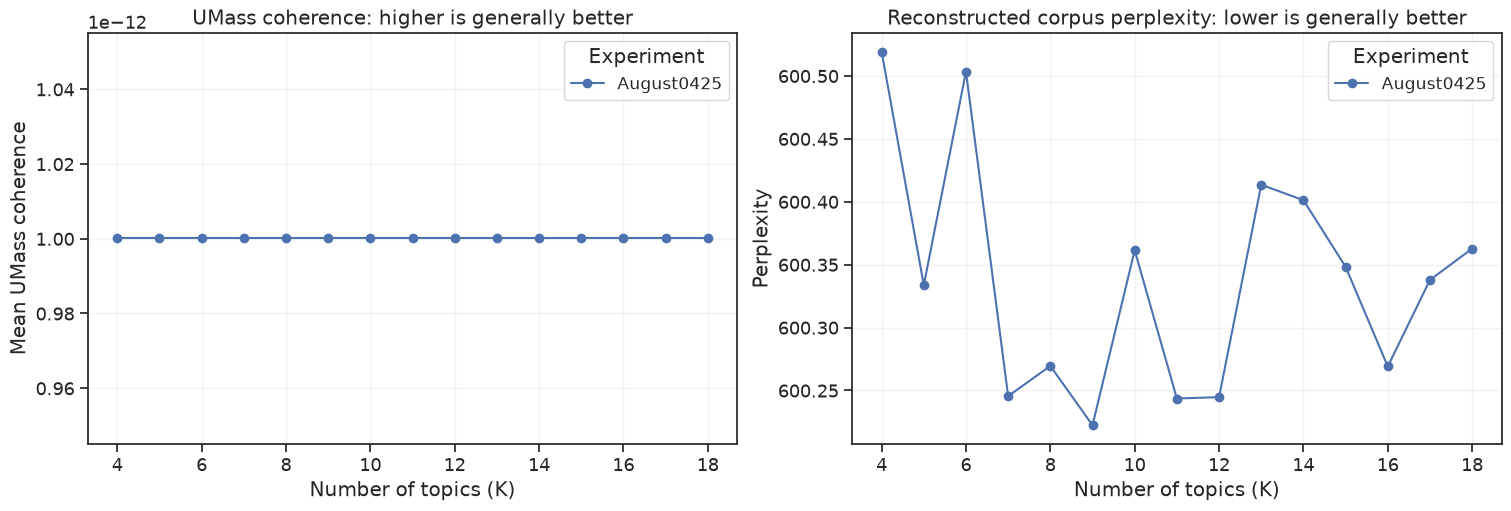

Saved comparison table: /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/topic_model_evaluation/perplexity_umass_comparison__August0425.csv
Saved comparison plot: /workspaces/Jerusalimiec-Dissertation/Text/Corpora/Concatenated/lemmatized/topic_model_evaluation/perplexity_umass_comparison__August0425.png


,experiment,run_dir,topics,u_mass_coherence,u_mass_min,u_mass_max,reconstructed_perplexity,documents,tokens,top_words
0,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,4,1.000089e-12,1.000089e-12,1.000089e-12,600.519373,2,90028,20
1,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,5,1.000089e-12,1.000089e-12,1.000089e-12,600.333730,2,90028,20
2,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,6,1.000089e-12,1.000089e-12,1.000089e-12,600.503332,2,90028,20
3,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,7,1.000089e-12,1.000089e-12,1.000089e-12,600.245528,2,90028,20
4,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,8,1.000089e-12,1.000089e-12,1.000089e-12,600.269483,2,90028,20
5,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,9,1.000089e-12,1.000089e-12,1.000089e-12,600.222374,2,90028,20
6,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,10,1.000089e-12,1.000089e-12,1.000089e-12,600.361418,2,90028,20
7,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,11,1.000089e-12,1.000089e-12,1.000089e-12,600.243611,2,90028,20
8,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,12,1.000089e-12,1.000089e-12,1.000089e-12,600.244693,2,90028,20
9,August0425,/workspaces/Jerusalimiec-Dissertation/Text/Cor...,13,1.000089e-12,1.000089e-12,1.000089e-12,600.413512,2,90028,20


In [19]:
from pathlib import Path
from collections import defaultdict
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _topic_number(path):
    """Extract K from a MALLET filename such as mallet.topic_keys.12."""
    match = re.search(r"\.(\d+)$", path.name)
    return int(match.group(1)) if match else None


def _find_preprocessed_pickle(run_dir):
    """Find the nearest preprocessed_docs.pkl above a topics_K directory."""
    for parent in [run_dir.parent, *run_dir.parents]:
        candidate = parent / "preprocessed_docs.pkl"
        if candidate.exists():
            return candidate
    return None


def discover_saved_runs(root=None):
    """Return experiment folders containing one or more topics_K folders."""
    root = (
        Path.cwd()
        if root is None
        else Path(root).expanduser().resolve()
    )
    grouped = defaultdict(list)

    for key_path in root.rglob("mallet.topic_keys.*"):
        if ".ipynb_checkpoints" in key_path.parts:
            continue

        topic_dir = key_path.parent

        if not re.fullmatch(r"topics_\d+", topic_dir.name):
            continue

        grouped[topic_dir.parent].append(topic_dir)

    runs = []

    for experiment_dir, topic_dirs in sorted(
        grouped.items(),
        key=lambda item: str(item[0]),
    ):
        topic_dirs = sorted(
            set(topic_dirs),
            key=lambda path: int(path.name.split("_")[-1]),
        )

        runs.append(
            {
                "experiment_dir": experiment_dir,
                "topic_dirs": topic_dirs,
                "preprocessed": _find_preprocessed_pickle(
                    topic_dirs[0]
                ),
            }
        )

    return runs


def choose_experiments(runs):
    """Interactively select one or more experiment folders."""
    if not runs:
        raise FileNotFoundError(
            "No topics_K folders were found below the current "
            "working directory."
        )

    print("Saved experiment folders:")

    for index, run in enumerate(runs, start=1):
        topic_counts = [
            path.name.split("_")[-1]
            for path in run["topic_dirs"]
        ]

        document_status = (
            "documents available"
            if run["preprocessed"]
            else "no matching preprocessed_docs.pkl"
        )

        try:
            relative_path = run["experiment_dir"].relative_to(
                Path.cwd()
            )
        except ValueError:
            relative_path = run["experiment_dir"]

        print(
            f"[{index}] {relative_path} "
            f"(K={', '.join(topic_counts)}; "
            f"{document_status})"
        )

    while True:
        try:
            response = input(
                "Select experiment number(s), ranges such as 1-3, "
                "'all', or type 'cancel' and press Enter "
                "[default: all]: "
            ).strip().lower()

        except (KeyboardInterrupt, EOFError):
            print("\nSelection cancelled.")
            return None

        if response in {"cancel", "c", "esc", "escape"}:
            print("Selection cancelled.")
            return None

        if not response or response == "all":
            return runs

        selected = set()

        for part in response.split(","):
            part = part.strip()

            try:
                if "-" in part:
                    start, end = [
                        int(value.strip())
                        for value in part.split("-", 1)
                    ]

                    selected.update(
                        range(
                            min(start, end),
                            max(start, end) + 1,
                        )
                    )
                else:
                    selected.add(int(part))

            except ValueError:
                print(
                    f"Ignoring invalid selection: {part!r}"
                )

        selected_runs = [
            run
            for index, run in enumerate(runs, start=1)
            if index in selected
        ]

        if selected_runs:
            return selected_runs

        print(
            "No valid experiments selected; please try again."
        )


def load_training_documents(preprocessed_path):
    """Load filtered documents and filenames from preprocessed_docs.pkl."""
    with open(preprocessed_path, "rb") as handle:
        training_docs, _, target_files = pickle.load(handle)

    return list(training_docs), list(target_files)


def load_topic_words(topic_dir, top_n=20):
    """Read MALLET's top words from mallet.topic_keys.K."""
    num_topics = topic_dir.name.split("_")[-1]
    key_path = topic_dir / f"mallet.topic_keys.{num_topics}"

    topics = []

    with open(key_path, encoding="utf-8") as handle:
        for line in handle:
            fields = line.split()

            if len(fields) >= 3:
                topics.append(fields[2:2 + top_n])

    return topics


def load_document_topics(topic_dir, num_topics):
    """Read theta[d, k] from MALLET's topic-distribution output."""
    path = (
        topic_dir
        / f"mallet.topic_distributions.{num_topics}"
    )
    rows = []

    with open(path, encoding="utf-8") as handle:
        for line in handle:
            fields = line.split()

            if len(fields) > 2:
                rows.append(
                    [float(value) for value in fields[2:]]
                )

    theta = np.asarray(rows, dtype=float)

    if theta.ndim != 2 or theta.shape[1] != num_topics:
        raise ValueError(
            f"Expected {num_topics} topic probabilities in "
            f"{path}; found shape {theta.shape}."
        )

    row_totals = theta.sum(axis=1, keepdims=True)

    if np.any(row_totals == 0):
        raise ValueError(
            f"One or more document-topic rows in {path} "
            "sum to zero."
        )

    return theta / row_totals


def load_topic_word_probabilities(topic_dir, num_topics):
    """Read and normalize MALLET's topic-word weights."""
    path = topic_dir / f"mallet.word_weights.{num_topics}"
    by_topic = defaultdict(dict)

    with open(path, encoding="utf-8") as handle:
        for line in handle:
            fields = line.split()

            if len(fields) == 3:
                topic, word, weight = (
                    int(fields[0]),
                    fields[1],
                    float(fields[2]),
                )
                by_topic[topic][word] = weight

    if len(by_topic) != num_topics:
        raise ValueError(
            f"Expected weights for {num_topics} topics in "
            f"{path}; found {len(by_topic)}."
        )

    phi = []

    for topic in range(num_topics):
        weights = by_topic[topic]
        total = sum(weights.values())

        if total <= 0:
            raise ValueError(
                f"Topic {topic} in {path} has no positive weights."
            )

        phi.append(
            {
                word: weight / total
                for word, weight in weights.items()
            }
        )

    return phi


def reconstructed_perplexity(training_docs, theta, phi):
    """Calculate perplexity reconstructed on the training corpus."""
    if len(training_docs) != len(theta):
        raise ValueError(
            f"Document count mismatch: {len(training_docs)} "
            f"documents versus {len(theta)} distributions."
        )

    log_likelihood = 0.0
    token_count = 0
    floor = 1e-12

    for document, topic_mix in zip(training_docs, theta):
        for word in document.split():
            probability = sum(
                topic_mix[topic]
                * phi[topic].get(word, floor)
                for topic in range(len(phi))
            )

            log_likelihood += np.log(
                max(probability, floor)
            )
            token_count += 1

    return (
        float(np.exp(-log_likelihood / token_count))
        if token_count
        else np.nan
    )


def umass_coherence(
    training_docs,
    topic_words,
    top_n=20,
    epsilon=1e-12,
):
    """Calculate mean UMass coherence across topics."""
    document_sets = [
        set(document.split())
        for document in training_docs
    ]

    document_frequency = defaultdict(int)

    for document in document_sets:
        for word in document:
            document_frequency[word] += 1

    scores = []

    for words in topic_words:
        words = words[:top_n]
        pair_scores = []

        for m in range(1, len(words)):
            for l in range(m):
                denominator = document_frequency[words[l]]

                cooccurrence = sum(
                    words[m] in document
                    and words[l] in document
                    for document in document_sets
                )

                pair_scores.append(
                    np.log(
                        (cooccurrence + epsilon)
                        / max(denominator, 1)
                    )
                )

        scores.append(
            float(np.mean(pair_scores))
            if pair_scores
            else np.nan
        )

    return np.asarray(scores, dtype=float)


def evaluate_topic_dir(
    topic_dir,
    training_docs,
    target_files,
    top_n=20,
):
    """Calculate UMass coherence and reconstructed perplexity."""
    num_topics = int(
        topic_dir.name.split("_")[-1]
    )

    filenames_path = topic_dir / "input_filenames.txt"

    with open(filenames_path, encoding="utf-8") as handle:
        run_files = [
            line.strip()
            for line in handle
            if line.strip()
        ]

    if run_files != target_files:
        raise ValueError(
            "preprocessed_docs.pkl and input_filenames.txt "
            "contain different files or orders."
        )

    topic_words = load_topic_words(
        topic_dir,
        top_n=top_n,
    )

    theta = load_document_topics(
        topic_dir,
        num_topics,
    )

    phi = load_topic_word_probabilities(
        topic_dir,
        num_topics,
    )

    coherence_scores = umass_coherence(
        training_docs,
        topic_words,
        top_n=top_n,
    )

    return {
        "experiment": topic_dir.parent.name,
        "run_dir": str(topic_dir),
        "topics": num_topics,
        "u_mass_coherence": float(
            np.nanmean(coherence_scores)
        ),
        "u_mass_min": float(
            np.nanmin(coherence_scores)
        ),
        "u_mass_max": float(
            np.nanmax(coherence_scores)
        ),
        "reconstructed_perplexity": reconstructed_perplexity(
            training_docs,
            theta,
            phi,
        ),
        "documents": len(training_docs),
        "tokens": sum(
            len(document.split())
            for document in training_docs
        ),
        "top_words": top_n,
    }


def _safe_filename_part(value):
    return (
        re.sub(
            r"[^A-Za-z0-9._-]+",
            "-",
            str(value),
        ).strip("-._")
        or "unnamed-run"
    )


def evaluate_saved_models(top_n=20, root=None):
    """Evaluate saved models and save comparisons."""
    runs = discover_saved_runs(root)
    selected_runs = choose_experiments(runs)

    if not selected_runs:
        print("No experiments selected.")
        return pd.DataFrame()

    rows = []

    for run in selected_runs:
        if run["preprocessed"] is None:
            print(
                f"Skipping {run['experiment_dir']}: "
                "no matching preprocessed_docs.pkl was found."
            )
            continue

        try:
            training_docs, target_files = (
                load_training_documents(
                    run["preprocessed"]
                )
            )

            for topic_dir in run["topic_dirs"]:
                try:
                    row = evaluate_topic_dir(
                        topic_dir,
                        training_docs,
                        target_files,
                        top_n=top_n,
                    )

                    rows.append(row)

                    print(
                        f"Evaluated {topic_dir}: "
                        f"u_mass="
                        f"{row['u_mass_coherence']:.4f}; "
                        f"reconstructed perplexity="
                        f"{row['reconstructed_perplexity']:.2f}"
                    )

                except Exception as error:
                    print(
                        f"Skipping {topic_dir}: {error}"
                    )

        except Exception as error:
            print(
                f"Skipping {run['experiment_dir']}: {error}"
            )

    if not rows:
        print("No models could be evaluated.")
        return pd.DataFrame()

    results = (
        pd.DataFrame(rows)
        .sort_values(["experiment", "topics"])
        .reset_index(drop=True)
    )

    output_dir = Path.cwd() / "topic_model_evaluation"
    output_dir.mkdir(exist_ok=True)

    comparison_label = "__".join(
        sorted(
            {
                _safe_filename_part(
                    run["experiment_dir"].name
                )
                for run in selected_runs
            }
        )
    )

    output_stem = (
        f"perplexity_umass_comparison__{comparison_label}"
    )

    csv_path = output_dir / f"{output_stem}.csv"
    results.to_csv(csv_path, index=False)

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5),
        constrained_layout=True,
    )

    for experiment, group in results.groupby("experiment"):
        axes[0].plot(
            group["topics"],
            group["u_mass_coherence"],
            marker="o",
            label=experiment,
        )

        axes[1].plot(
            group["topics"],
            group["reconstructed_perplexity"],
            marker="o",
            label=experiment,
        )

    axes[0].set_title(
        "UMass coherence: higher is generally better"
    )
    axes[0].set_xlabel("Number of topics (K)")
    axes[0].set_ylabel("Mean UMass coherence")

    axes[1].set_title(
        "Reconstructed corpus perplexity: "
        "lower is generally better"
    )
    axes[1].set_xlabel("Number of topics (K)")
    axes[1].set_ylabel("Perplexity")

    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend(
            title="Experiment",
            fontsize="small",
        )

    plot_path = output_dir / f"{output_stem}.png"
    figure.savefig(plot_path, dpi=200)
    plt.show()

    print(f"Saved comparison table: {csv_path}")
    print(f"Saved comparison plot: {plot_path}")

    return results


try:
    results = evaluate_saved_models(top_n=20)
    display(results)

except (KeyboardInterrupt, EOFError):
    print("\nCell execution cancelled.")